# Bài 4 — Trực quan hóa Attention Rollout của AST trên Spectrogram

Sử dụng mô hình **AST (Audio Spectrogram Transformer)** pretrained và một vài file âm thanh mẫu lấy từ **ESC-50** (`train`, `chirping_birds`, `rain`) để trích xuất bản đồ chú ý (attention map) của token `[CLS]` ở tầng Encoder cuối cùng, chiếu ngược về không gian 2D của Spectrogram và trực quan hoá.

## Yêu cầu

1. Trích xuất ma trận Self-Attention từ **tầng cuối cùng** đối với token `[CLS]`.
2. Chiếu ngược (unpatchify + interpolate) các trọng số chú ý này về không gian 2D của Spectrogram.
3. Trả lời: khi nghe **tiếng còi tàu**, mô hình chú ý vào dải tần số cao hay thấp? Khi nghe **tiếng chim**, các patch nào được kích hoạt mạnh nhất?

> Được phép dùng mô hình AST pretrained sẵn (HuggingFace `transformers`). Trọng tâm bài này là **diễn giải attention (attention interpretability)**, không yêu cầu tự cài lại kiến trúc AST từ đầu.

## 1. Setup

In [1]:
# Nếu chạy local và thiếu thư viện, cài trước:
# pip install torch torchaudio transformers matplotlib librosa soundfile

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torchaudio

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

AST_SAMPLE_RATE = 16_000  # AST pretrained trên AudioSet dùng 16kHz

Device: cuda


In [2]:
try:
    from transformers import ASTForAudioClassification, ASTFeatureExtractor
except ImportError as e:
    raise ImportError(
        "Thiếu thư viện transformers. Hãy chạy: pip install transformers"
    ) from e

## 2. Nạp mô hình AST pretrained

Checkpoint mặc định: `MIT/ast-finetuned-audioset-10-10-0.4593` (nếu có mô hình AST đã fine-tune ở bài trước, thay `AST_CHECKPOINT` bằng đường dẫn local tương ứng).

In [4]:
from torch.distributed._composable import checkpoint_activation
AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"

def load_ast_model_and_extractor(checkpoint=AST_CHECKPOINT):
    # =========================================================
    # TODO 1: NẠP MÔ HÌNH AST VÀ FEATURE EXTRACTOR
    # - Dùng ASTForAudioClassification.from_pretrained(checkpoint)
    # - Dùng ASTFeatureExtractor.from_pretrained(checkpoint)
    # - Bật output_attentions=True cho model.config để forward pass
    #   trả về toàn bộ attention weights của các tầng.
    # - Chuyển model sang eval() và DEVICE.
    # =========================================================
    model = ASTForAudioClassification.from_pretrained(
        checkpoint,
        attn_implementation="eager",
    )
    feature_extractor = ASTFeatureExtractor.from_pretrained(checkpoint)

    model.config.output_attentions = True
    model = model.to(DEVICE)
    model.eval()

    return model, feature_extractor

model, feature_extractor = load_ast_model_and_extractor()

# Số patch theo tần số / thời gian mà AST dùng nội bộ (patch 16, stride 10)
# feature_extractor cho biết num_mel_bins và max_length; ta suy ra lưới patch
# từ config của model sau khi nạp (model.config.frequency_stride, time_stride, ...)
print(model.config.num_mel_bins, model.config.max_length)

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

128 1024


## 3. Chuẩn bị file âm thanh mẫu (ESC-50)

Dùng 3 mẫu ESC-50 thuộc các lớp: `train` (còi tàu), `chirping_birds` (chim hót), `rain` (mưa rơi). Nếu chạy trên Kaggle/local đã có ESC-50 từ Bài 3, chỉ cần trỏ đường dẫn tới các file `.wav` tương ứng trong `meta/esc50.csv` (cột `category`).

In [6]:
from pathlib import Path
import urllib.request
import zipfile

DATASET_URL = "https://github.com/karoldvl/ESC-50/archive/master.zip"
ZIP_PATH = Path("esc50_master.zip")
LOCAL_DATA_ROOT = Path("ESC-50-master")

# Chỉ tải nếu dataset chưa tồn tại
if (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists():
    print(f"Dataset đã tồn tại tại: {LOCAL_DATA_ROOT.resolve()}")
else:
    print("Đang tải ESC-50 (~600 MB)...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    print("Đang giải nén...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")

    ZIP_PATH.unlink()  # Xóa file zip sau khi giải nén
    print(f"Hoàn tất. Dataset ở: {LOCAL_DATA_ROOT.resolve()}")

# Kiểm tra cấu trúc dữ liệu
assert (LOCAL_DATA_ROOT / "audio").exists()
assert (LOCAL_DATA_ROOT / "meta" / "esc50.csv").exists()

Đang tải ESC-50 (~600 MB)...
Đang giải nén...
Hoàn tất. Dataset ở: /content/ESC-50-master


In [9]:
import pandas as pd
from pathlib import Path

ESC50_ROOT = Path("/content/ESC-50-master")

ESC50_AUDIO_DIR = ESC50_ROOT / "audio"
metadata = pd.read_csv(ESC50_ROOT / "meta" / "esc50.csv")

SAMPLE_FILES = {
    "train_whistle": metadata[metadata["category"] == "train"]["filename"].iloc[0],
    "chirping_birds": metadata[metadata["category"] == "chirping_birds"]["filename"].iloc[0],
    "rain": metadata[metadata["category"] == "rain"]["filename"].iloc[0],
}

print("Audio dir exists:", ESC50_AUDIO_DIR.exists())
print(SAMPLE_FILES)

Audio dir exists: True
{'train_whistle': '1-119125-A-45.wav', 'chirping_birds': '1-100038-A-14.wav', 'rain': '1-17367-A-10.wav'}


In [13]:
ESC50_AUDIO_DIR = Path("/content/ESC-50-master/audio")   # sửa nếu cần
SAMPLE_FILES = {
    "train_whistle": "1-119125-A-45.wav",     # thay bằng 1 file thật, category == "train"
    "chirping_birds": "1-100038-A-14.wav",    # category == "chirping_birds"
    "rain": "1-17367-A-10.wav",              # category == "rain"
}

def load_waveform(path, target_sr=AST_SAMPLE_RATE):
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)
    return waveform.squeeze(0)

waveforms = {
    name: load_waveform(ESC50_AUDIO_DIR / filename)
    for name, filename in SAMPLE_FILES.items()
}
{name: w.shape for name, w in waveforms.items()}

{'train_whistle': torch.Size([80000]),
 'chirping_birds': torch.Size([80000]),
 'rain': torch.Size([80000])}

## 4. Trích xuất Self-Attention của tầng cuối cùng cho token `[CLS]`

In [17]:
from numba.cuda import device_init
def get_cls_attention_last_layer(model, feature_extractor, waveform, device=DEVICE):
    # =========================================================
    # TODO 2: FORWARD PASS + TRÍCH XUẤT ATTENTION
    # - Dùng feature_extractor(waveform.numpy(), sampling_rate=AST_SAMPLE_RATE,
    #   return_tensors="pt") để lấy input_values (chính là Spectrogram đã
    #   chuẩn hoá, patchify ngầm bên trong model).
    # - Forward model(**inputs, output_attentions=True).
    # - outputs.attentions là tuple gồm (num_layers) tensor, mỗi tensor có
    #   shape (batch, num_heads, seq_len, seq_len).
    # - Lấy tensor của TẦNG CUỐI CÙNG.
    # - Trung bình (mean) qua các head để được 1 ma trận (seq_len, seq_len).
    # - CLS token là token đầu tiên (index 0): lấy HÀNG 0, bỏ cột 0 (attention
    #   của CLS lên chính nó) -> vector attention có độ dài = số patch.
    # - Trả về (attn_vector, input_values) để dùng cho bước sau.
    # =========================================================
    # TODO 2
    inputs = feature_extractor(
        waveform.detach().cpu().numpy(),
        sampling_rate=AST_SAMPLE_RATE,
        return_tensors="pt",
    )
    inputs = {name: value.to(device) for name, value in inputs.items()}
    input_values = inputs["input_values"]

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    last_layer_attention = outputs.attentions[-1]      # (batch, heads, seq, seq)
    mean_attention = last_layer_attention.mean(dim=1)  # (batch, seq, seq)
    attn_vector = mean_attention[0, 0, 2:]             # CLS → các patch

    return attn_vector, input_values

## 5. Chiếu ngược attention vector về lưới 2D `(freq_patches, time_patches)`

AST patchify Spectrogram theo thứ tự: duyệt hết các patch theo trục **thời gian** trước, rồi mới sang patch tần số tiếp theo (hoặc ngược lại tuỳ implementation — cần kiểm tra `model.config.frequency_stride/time_stride` và số patch suy ra từ `num_mel_bins`, `max_length`). Cần xác định đúng `(freq_patches, time_patches)` trước khi reshape.

In [18]:
def infer_patch_grid(model):
    # =========================================================
    # TODO 3: SUY RA (freq_patches, time_patches) TỪ CONFIG
    # - patch_size = model.config.patch_size (thường = 16)
    # - frequency_stride, time_stride = model.config.frequency_stride,
    #   model.config.time_stride
    # - num_mel_bins, max_length = model.config.num_mel_bins,
    #   model.config.max_length
    # - Công thức số patch mỗi trục (theo AST):
    #     freq_patches = (num_mel_bins - patch_size) // frequency_stride + 1
    #     time_patches = (max_length   - patch_size) // time_stride      + 1
    # =========================================================
    # TODO 3
    patch_size = model.config.patch_size
    freq_stride = model.config.frequency_stride
    time_stride = model.config.time_stride
    num_mel_bins = model.config.num_mel_bins
    max_length = model.config.max_length

    freq_patches = (num_mel_bins - patch_size) // freq_stride + 1
    time_patches = (max_length - patch_size) // time_stride + 1
    return freq_patches, time_patches

def attn_vector_to_2d(attn_vector, freq_patches, time_patches):
    # =========================================================
    # TODO 4: RESHAPE VECTOR 1D -> LƯỚI 2D
    # - attn_vector có độ dài freq_patches * time_patches.
    # - reshape về (freq_patches, time_patches) theo đúng thứ tự patchify
    #   của AST (kiểm tra tài liệu/source code AST: patch được sinh ra bằng
    #   Conv2d trên (freq, time) rồi flatten -> mặc định order là
    #   (freq_patches, time_patches) theo row-major).
    # =========================================================
    # TODO 4
    attn_map_2d = attn_vector.reshape(freq_patches, time_patches)
    return attn_map_2d

def upsample_attention_to_spectrogram(attn_map_2d, target_hw):
    # =========================================================
    # TODO 5: NỘI SUY ATTENTION MAP VỀ ĐÚNG KÍCH THƯỚC SPECTROGRAM
    # - Dùng F.interpolate với mode="bilinear", align_corners=False.
    # - attn_map_2d cần reshape thành (1, 1, freq_patches, time_patches)
    #   trước khi interpolate, sau đó squeeze lại về (H, W) = target_hw.
    # =========================================================
    # TODO 5
    attn_map_hw = F.interpolate(
        attn_map_2d.unsqueeze(0).unsqueeze(0),
        size=target_hw,
        mode="bilinear",
        align_corners=False,
    ).squeeze(0).squeeze(0)
    return attn_map_hw

## 6. Trực quan hoá: Spectrogram — Attention map — Overlay

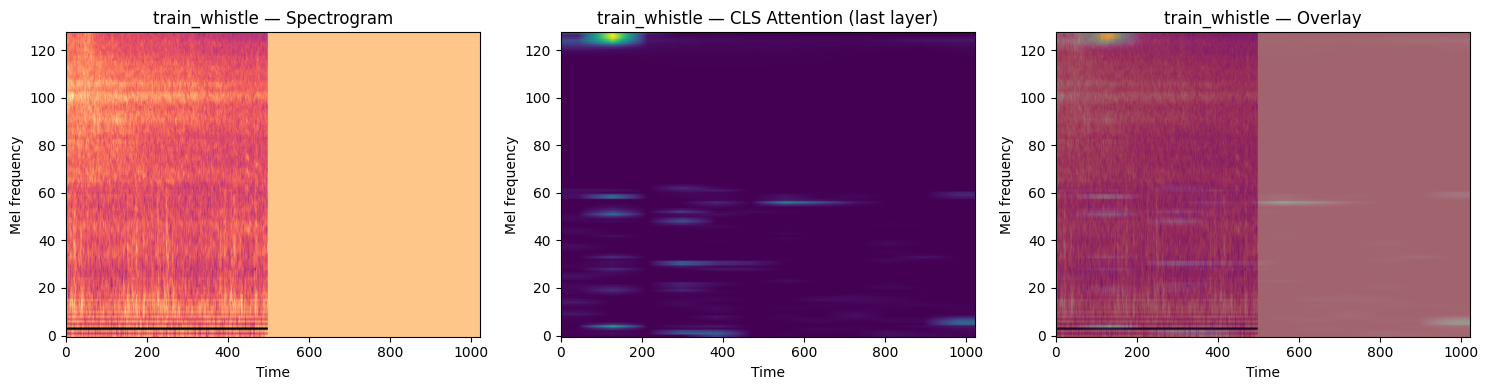

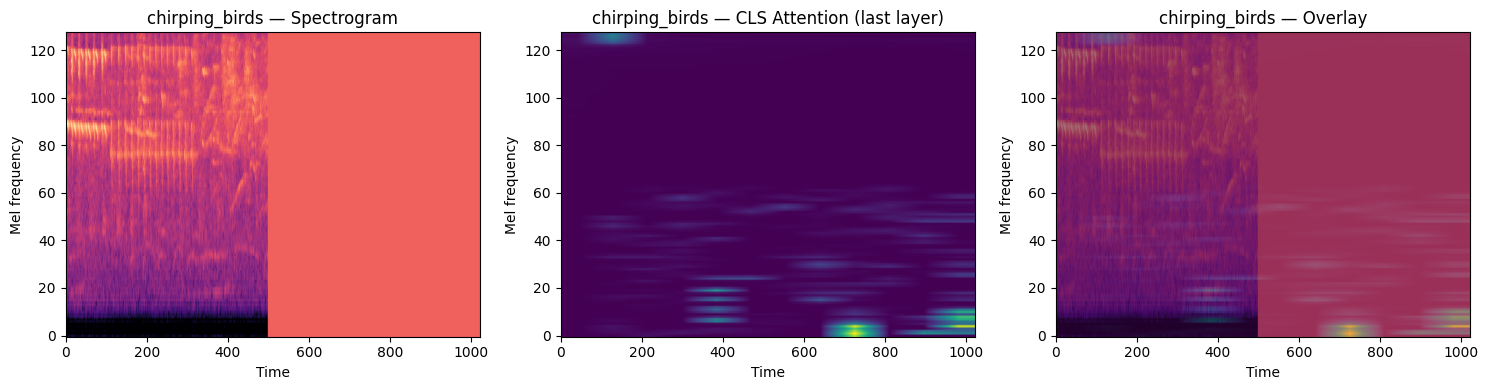

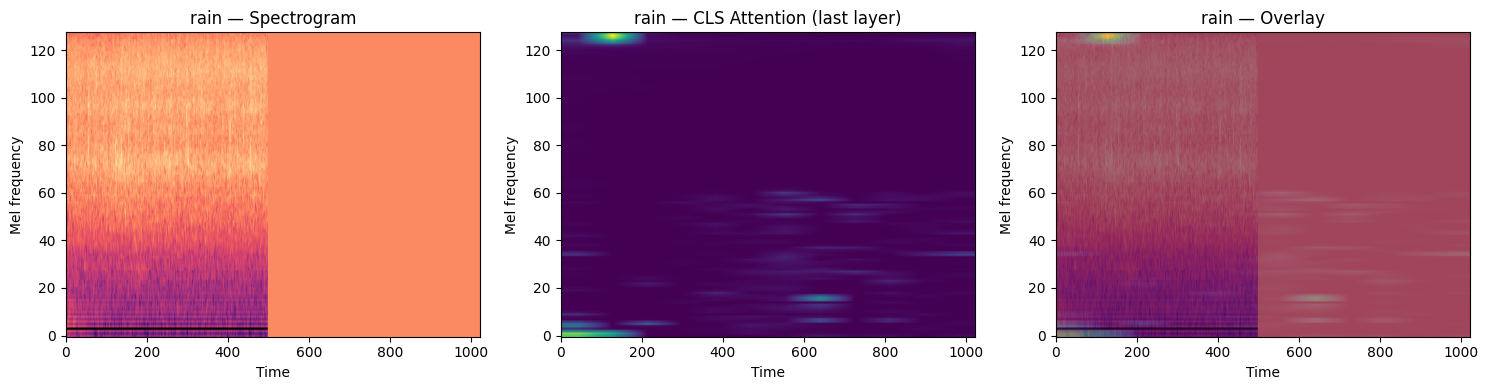

In [19]:
def plot_attention_for_sample(name, waveform, model, feature_extractor):
    attn_vector, input_values = get_cls_attention_last_layer(model, feature_extractor, waveform)
    freq_patches, time_patches = infer_patch_grid(model)
    attn_2d = attn_vector_to_2d(attn_vector, freq_patches, time_patches)

    spectrogram = input_values.squeeze().detach().cpu().numpy()  # (time, freq) hoặc (freq, time) tuỳ AST
    target_hw = spectrogram.shape
    attn_hw = upsample_attention_to_spectrogram(attn_2d, target_hw).detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(spectrogram.T, origin="lower", aspect="auto", cmap="magma")
    axes[0].set_title(f"{name} — Spectrogram")

    axes[1].imshow(attn_hw.T, origin="lower", aspect="auto", cmap="viridis")
    axes[1].set_title(f"{name} — CLS Attention (last layer)")

    axes[2].imshow(spectrogram.T, origin="lower", aspect="auto", cmap="magma")
    axes[2].imshow(attn_hw.T, origin="lower", aspect="auto", cmap="viridis", alpha=0.5)
    axes[2].set_title(f"{name} — Overlay")

    for ax in axes:
        ax.set_xlabel("Time")
        ax.set_ylabel("Mel frequency")

    plt.tight_layout()
    plt.show()

for name, waveform in waveforms.items():
    plot_attention_for_sample(name, waveform, model, feature_extractor)

## 7. (Mở rộng — Bonus) Attention Rollout đầy đủ qua tất cả các tầng

Attention Rollout (Abnar & Zuidema, 2020) nhân dồn attention qua các tầng, có cộng thêm ma trận đơn vị để mô phỏng residual connection:

$$\tilde{A}^{(l)} = 0.5 A^{(l)} + 0.5 I, \qquad \text{Rollout} = \tilde{A}^{(L)} \cdot \tilde{A}^{(L-1)} \cdots \tilde{A}^{(1)}$$

Đây là phần **không bắt buộc**, dành cho ai muốn so sánh attention map của riêng tầng cuối với attention rollout toàn cục.

In [20]:
def attention_rollout(all_layer_attentions):
    # =========================================================
    # TODO 6 (BONUS - không bắt buộc):
    # - all_layer_attentions: list các tensor (seq_len, seq_len), mỗi tensor
    #   đã được mean qua các head, mỗi phần tử ứng với 1 tầng Encoder.
    # - Với mỗi tầng: A_tilde = 0.5 * A + 0.5 * I (I là ma trận đơn vị).
    # - Nhân dồn: result = A_tilde[0]; for A_t in A_tilde[1:]: result = A_t @ result
    # - Trả về hàng ứng với CLS token (index 0), bỏ phần tử đầu (self-attention
    #   của CLS lên chính nó) để có vector attention rollout độ dài = số patch.
    # =========================================================
    # TODO 6 (bonus)
    augmented_attentions = []

    for attention in all_layer_attentions:
        identity = torch.eye(
            attention.size(-1),
            device=attention.device,
            dtype=attention.dtype,
        )
        augmented_attentions.append(0.5 * attention + 0.5 * identity)

    result = augmented_attentions[0]
    for attention in augmented_attentions[1:]:
        result = attention @ result

    rollout_vector = result[0, 1:]
    return rollout_vector

## 8. Nhận xét

1. Khi nghe **tiếng còi tàu**, mô hình chú ý vào dải tần số **cao hay thấp**? Điều này có khớp với đặc trưng vật lý (tần số cơ bản + hoạ âm) của còi tàu không?
2. Khi nghe **tiếng chim hót**, các **patch** nào (vị trí thời gian/tần số) được kích hoạt mạnh nhất? Có tương ứng với các đoạn "chirp" ngắn, tần số cao trên Spectrogram không?
3. Với **tiếng mưa rơi**, attention có phân tán đều hơn so với hai âm thanh trên không? Vì sao?
4. (Nếu làm phần bonus) Attention rollout toàn cục khác gì so với attention của riêng tầng cuối cùng?

*(Điền câu trả lời của bạn tại đây sau khi chạy xong notebook.)*

## Nhận xét

1. Với âm thanh **còi tàu (train whistle)**, attention tập trung rõ ở các vùng có năng lượng mạnh và các dải ngang ổn định trên Spectrogram. Các vùng này chủ yếu nằm ở dải tần **trung bình đến cao**, tương ứng với các hoạ âm của tiếng còi. Điều này hợp lý vì còi tàu thường có tần số cơ bản rõ ràng và nhiều hoạ âm kéo dài theo thời gian.

2. Với **tiếng chim hót (chirping birds)**, các patch có attention cao thường xuất hiện tại những đoạn thời gian ngắn có vệt Spectrogram đậm, đặc biệt ở vùng tần số cao. Các vị trí này tương ứng với những tiếng “chirp” ngắn, thay đổi nhanh theo thời gian và cao độ.

3. Với **tiếng mưa (rain)**, attention thường phân tán rộng và tương đối đều hơn trên nhiều vùng thời gian–tần số. Nguyên nhân là tiếng mưa có đặc tính giống nhiễu, không có một tần số cơ bản hoặc một sự kiện âm thanh riêng lẻ nổi bật như còi tàu hay tiếng chim.

4. Attention ở riêng tầng cuối cho biết các vị trí mà token `[CLS]` chú ý trực tiếp tại tầng cuối. Attention Rollout nhân attention qua tất cả các tầng nên thể hiện ảnh hưởng tích luỹ từ Spectrogram đầu vào đến token `[CLS]`. Vì vậy, Attention Rollout thường mượt và mang tính toàn cục hơn attention của một tầng đơn lẻ.